In [ ]:
!pip install pyspark pandas matplotlib
!pip install python-dotenv



In [ ]:
from dotenv import load_dotenv
import os

load_dotenv('.env')

BOOTSTRAP_SERVERS = os.getenv('BOOTSTRAP_SERVERS')
API_KEY = os.getenv('API_KEY')
API_SECRET = os.getenv('API_SECRET')
TOPIC = "incidents_stream"

In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("IncidentsStreamingConsumer")
    .master("local[*]")
    .config(
        "spark.jars.packages",
        "org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.0"
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark


In [ ]:
from pyspark.sql.functions import col, from_json, expr
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

incident_schema = StructType([
    StructField("id",           StringType(), True),
    StructField("reported_at",  StringType(), True),
    StructField("lat",          DoubleType(), True),
    StructField("lon",          DoubleType(), True),
    StructField("alert_code",   StringType(), True),
    StructField("description",  StringType(), True),
    StructField("tag",          StringType(), True),
])

# configurare Confluent Cloud
jaas_template = (
    'org.apache.kafka.common.security.plain.PlainLoginModule required '
    'username="{username}" password="{password}";'
)
jaas_cfg = jaas_template.format(username=API_KEY, password=API_SECRET)

kafka_options = {
    "kafka.bootstrap.servers": BOOTSTRAP_SERVERS,
    "kafka.security.protocol": "SASL_SSL",
    "kafka.sasl.mechanism": "PLAIN",
    "kafka.sasl.jaas.config": jaas_cfg,
    "subscribe": TOPIC,
    "startingOffsets": "latest",
}

raw_stream = (
    spark.readStream
    .format("kafka")
    .options(**kafka_options)
    .load()
)

json_stream = raw_stream.selectExpr("CAST(value AS STRING) as json_str")

parsed_stream = (
    json_stream
    .select(from_json(col("json_str"), incident_schema).alias("data"))
    .select("data.*")
)

# convertim reported_at -> timestamp Spark
incidents_stream = parsed_stream.withColumn(
    "reported_at_ts",
    expr("to_timestamp(reported_at)")
)

incidents_stream.printSchema()


root
 |-- id: string (nullable = true)
 |-- reported_at: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- alert_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- tag: string (nullable = true)
 |-- reported_at_ts: timestamp (nullable = true)



In [5]:
from pyspark.sql.functions import window

# Agregare simplă pe ferestre de 1 minut și alert_code
agg_by_type = (
    incidents_stream
    .groupBy(
        window(col("reported_at_ts"), "1 minute"),
        col("alert_code")
    )
    .count()
)

query = (
    agg_by_type
    .writeStream
    .outputMode("complete")
    .format("memory")          # tabel in-memory
    .queryName("incidents_by_type")
    .start()
)

print("Streaming query started. Lasă producer-ul să trimită mesaje câteva secunde...")


Streaming query started. Lasă producer-ul să trimită mesaje câteva secunde...


In [ ]:
import time
import pandas as pd

# așteptăm 5 secunde pentru date din producer
time.sleep(5)

pdf = spark.sql("""
    SELECT
        window.start AS window_start,
        window.end   AS window_end,
        alert_code,
        count
    FROM incidents_by_type
    ORDER BY window_start, alert_code
""").toPandas()

pdf.tail()


,window_start,window_end,alert_code,count
18,2025-11-23 17:19:00,2025-11-23 17:20:00,OTHER,4
19,2025-11-23 17:19:00,2025-11-23 17:20:00,PROTEST,6
20,2025-11-23 17:20:00,2025-11-23 17:21:00,ACCIDENT,1
21,2025-11-23 17:20:00,2025-11-23 17:21:00,FIRE,2
22,2025-11-23 17:20:00,2025-11-23 17:21:00,OTHER,2


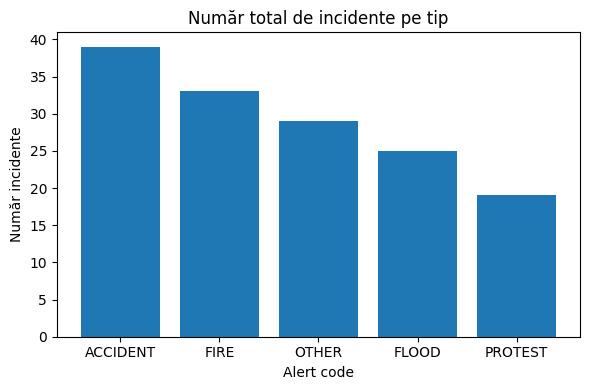

In [19]:
import matplotlib.pyplot as plt

if pdf.empty:
    print("Nu sunt încă date. Lasă streaming-ul să meargă și rulează din nou celula.")
else:
    totals = (
        pdf.groupby("alert_code")["count"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(6, 4))
    plt.bar(totals.index, totals.values)
    plt.xlabel("Alert code")
    plt.ylabel("Număr incidente")
    plt.title("Număr total de incidente pe tip")
    plt.tight_layout()
    plt.show()


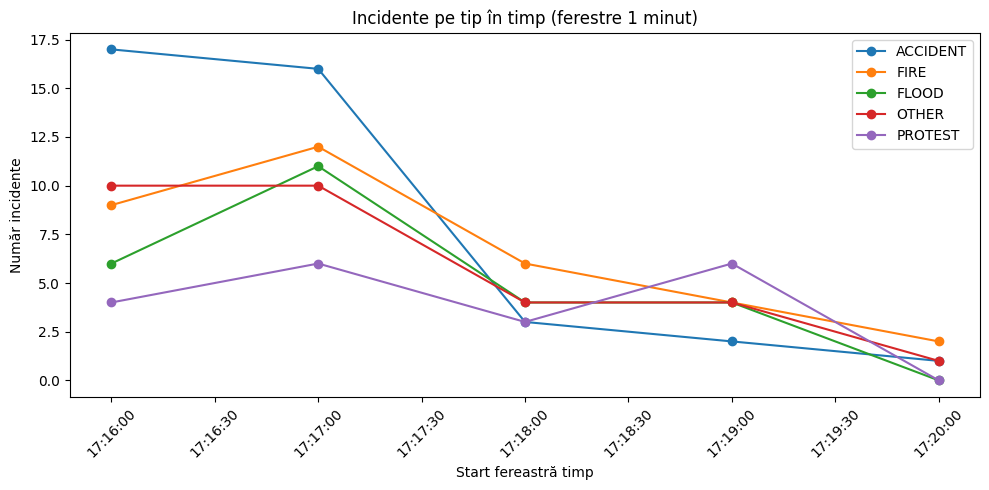

In [20]:
if pdf.empty:
    print("Nu sunt încă date. Lasă streaming-ul să meargă și rulează din nou celula.")
else:
    pivot = pdf.pivot_table(
        index="window_start",
        columns="alert_code",
        values="count",
        aggfunc="sum",
        fill_value=0,
    )

    plt.figure(figsize=(10, 5))
    for code in pivot.columns:
        plt.plot(pivot.index, pivot[code], marker="o", label=code)

    plt.xlabel("Start fereastră timp")
    plt.ylabel("Număr incidente")
    plt.title("Incidente pe tip în timp (ferestre 1 minut)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
